**1. What is Deep Learning? Briefly describe how it evolved and how it differs from traditional machine learning.**

Deep Learning is a subset of Machine Learning that uses artificial neural networks with multiple hidden layers to learn patterns and representations from data automatically.

Deep learning is inspired by the structure and functioning of the human brain. It is widely used in image recognition, speech processing, NLP, and autonomous systems.

Evolution of Deep Learning:

1950s–1980s: Introduction of perceptrons and basic neural networks.

1990s: Limited growth due to low computational power and insufficient data.

2000s: Availability of GPUs and large datasets improved neural network training.

2010s–Present: Deep learning became popular with architectures like CNNs, RNNs, and Transformers.

**2. Explain the basic architecture and functioning of a Perceptron. What are its limitations?**

A Perceptron is the simplest type of artificial neural network used for binary classification tasks.

Basic Architecture:

A perceptron contains:

Input layer
Weights
Bias
Activation function
Output
Working of a Perceptron:
Inputs are multiplied by weights.
Weighted inputs are summed with bias.
Activation function produces the final output.

Limitations:
Can solve only linearly separable problems.
Cannot solve XOR problem.
Limited learning capability compared to multilayer networks.

**3. Describe the purpose of activation function in neural networks. Compare Sigmoid, ReLU, and Tanh functions.**

Activation functions introduce non-linearity into neural networks, enabling them to learn complex patterns.

Without activation functions, neural networks behave like linear models.

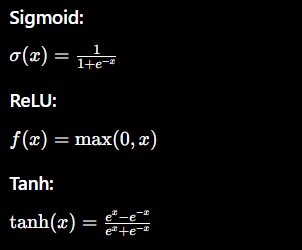

- The Sigmoid function compresses input values into a probability-like range between 0 and 1.

- ReLU is currently the standard default activation function because of its simplicity and efficiency.

- Tanh maps input values to a range between -1 and 1, producing a zero-centered output.

**4. What is the difference between Loss function and Cost function in neural networks? Provide examples.**

In neural networks, a loss function measures the error for a single training example. A cost function is the average (or aggregate) of these individual loss values across the entire dataset (or a batch).While the terms are often used interchangeably, the loss function guides individual predictions, and the cost function guides overall model optimization.

Examples:

Loss Functions:

Binary Crossentropy
Mean Squared Error (MSE)

Cost Functions:

Average MSE over all samples
Average Crossentropy Loss

**5. What is the role of optimizers in neural networks? Compare Gradient Descent, Adam, and RMSprop.**

Optimizers are algorithms used in neural networks to adjust the model's weights and biases. Their primary role is to minimize the loss function, bringing the network's predictions closer to the actual target values by determining exactly how much to alter the network parameters during backpropagation

Here is a comparison of Gradient Descent, Adam, and RMSprop:

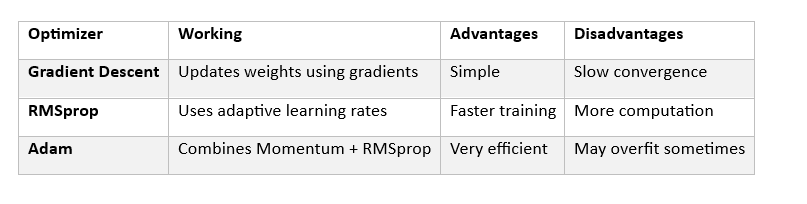

**6. Write a Python program to implement a single-layer perceptron from scratch using NumPy to solve the logical AND gate.**

In [1]:
import numpy as np

# Input dataset for AND gate
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

# Expected output
y = np.array([0, 0, 0, 1])

# Initialize weights and bias
weights = np.zeros(2)
bias = 0
learning_rate = 0.1

# Activation function
def step_function(x):
    return 1 if x >= 0 else 0

# Training
for epoch in range(10):
    for i in range(len(X)):
        linear_output = np.dot(X[i], weights) + bias
        prediction = step_function(linear_output)

        error = y[i] - prediction

        weights += learning_rate * error * X[i]
        bias += learning_rate * error

print("Weights:", weights)
print("Bias:", bias)

# Testing
print("\nPredictions:")
for i in range(len(X)):
    output = step_function(np.dot(X[i], weights) + bias)
    print(X[i], "->", output)

Weights: [0.2 0.1]
Bias: -0.20000000000000004

Predictions:
[0 0] -> 0
[0 1] -> 0
[1 0] -> 0
[1 1] -> 1


**7. Implement and visualize Sigmoid, ReLU, and Tanh activation functions using Matplotlib.**

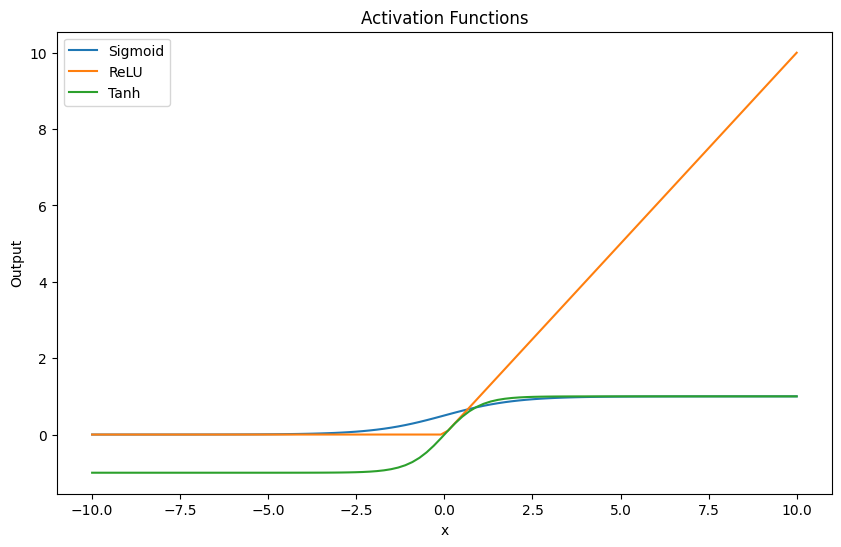

In [2]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 100)

# Activation functions
sigmoid = 1 / (1 + np.exp(-x))
relu = np.maximum(0, x)
tanh = np.tanh(x)

# Plotting
plt.figure(figsize=(10,6))

plt.plot(x, sigmoid, label='Sigmoid')
plt.plot(x, relu, label='ReLU')
plt.plot(x, tanh, label='Tanh')

plt.title("Activation Functions")
plt.xlabel("x")
plt.ylabel("Output")
plt.legend()

plt.show()

**8. Use Keras to build and train a simple multilayer neural network on the MNIST digits dataset. Print the training accuracy.**

In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.datasets import mnist

# Load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize data
X_train = X_train / 255.0
X_test = X_test / 255.0

# Build model
model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
history = model.fit(X_train, y_train, epochs=5)

# Evaluate
loss, accuracy = model.evaluate(X_test, y_test)

print("Training Accuracy:", accuracy)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9264 - loss: 0.2558
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9669 - loss: 0.1109
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9773 - loss: 0.0757
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9826 - loss: 0.0571
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9866 - loss: 0.0446
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9782 - loss: 0.0710
Training Accuracy: 0.9782000184059143


**9. Visualize the loss and accuracy curves for a neural network model trained on the Fashion MNIST dataset. Interpret the training behavior.**

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8248 - loss: 0.4957 - val_accuracy: 0.8428 - val_loss: 0.4448
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8623 - loss: 0.3797 - val_accuracy: 0.8406 - val_loss: 0.4276
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8753 - loss: 0.3400 - val_accuracy: 0.8526 - val_loss: 0.4053
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8839 - loss: 0.3166 - val_accuracy: 0.8647 - val_loss: 0.3730
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8887 - loss: 0.2982 - val_accuracy: 0.8758 - val_loss: 0.3503


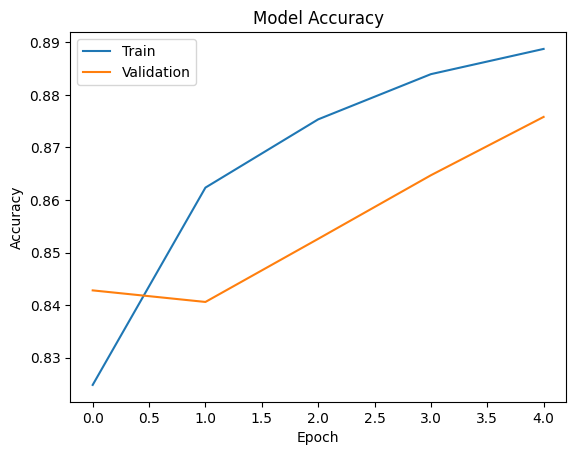

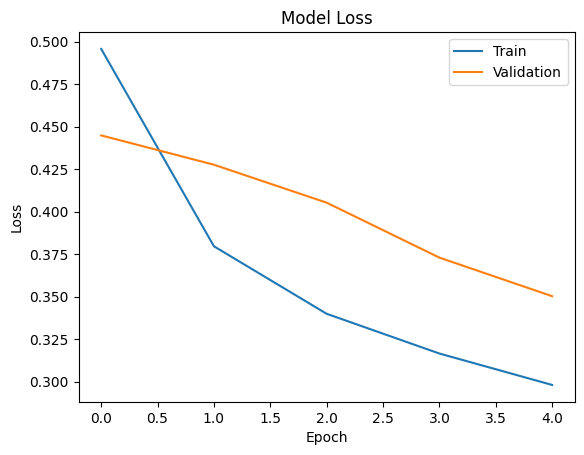

In [4]:
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

# Load dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

# Build model
model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    validation_data=(X_test, y_test)
)

# Plot accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

plt.show()

# Plot loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])

plt.show()

**Interpretation:**

Increasing accuracy indicates successful learning.

Decreasing loss indicates improved predictions.

If validation loss increases while training loss decreases, overfitting may occur.

**10. Fraud Detection System using Deep Learning**

Real-Time Data Science Workflow:
1. Data Collection

Collect transaction data such as:

Transaction amount

Merchant ID

Customer location

Device information

Transaction time

2. Data Preprocessing

Handle missing values

Normalize numerical features

Encode categorical variables

Remove duplicates

3. Model Design

Use a multilayer neural network with:

Input layer

Hidden layers with ReLU activation

Output layer with Sigmoid activation

4. Activation Function

ReLU for hidden layers because it trains faster.

Sigmoid for output because fraud detection is a binary classification problem.

5. Loss Function

Use Binary Crossentropy because the output has two classes:

Fraud

Legitimate

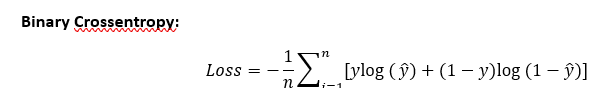

6. Handling Class Imbalance

Use:

SMOTE oversampling

Class weights

Precision, Recall, and F1-score instead of only accuracy

7. Optimizer

Use Adam optimizer because it provides fast and adaptive learning.

8. Preventing Overfitting

Dropout layers

Early stopping

Regularization

Cross-validation

**Sample Python Code:**

In [5]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Build model
model = Sequential([
    Dense(64, activation='relu', input_shape=(30,)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print(model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

None
